Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported

📂 LOADING MODEL AND SCALER FROM DRIVE
Looking for files in: /content/drive/MyDrive/DSGP_Test123_Files
✅ Found lstm_model.h5 (1.11 MB)
✅ Found scaler.pkl (0.00 MB)
✅ Found model_config.json (0.00 MB)
✅ Found feature_info.json (0.00 MB)


✅ Model loaded successfully with custom objects
✅ Scaler loaded successfully
✅ Model config loaded
   • Input shape: [6, 30]
   • Sequence length: 6
   • Forecast horizon: 6
   • Number of features: 30
✅ Feature info loaded: 30 features

📊 LOADING TRAINING STATISTICS
⚠️ Using data mean as training mean: 629.00

📂 LOADING TEST DATA FROM NOTEBOOK 3
✅ Loaded test data from Notebook 3 (may be scaled):
   X shape: (96, 6, 30)
   y shape: (96, 6)

🔍 Checking if data is already scaled...
X mean: -0.23, X std: 0.76
Sample values: [ 0.          1.         -0.32237403 -0.36390119 -0.44186592]
⚠️ Data appears ALREADY SCALED!

✅ Using already scaled data - skipping scaling step
   X shape: (96, 6, 30)

🔍 CHECKING FOR NaN VALUES AFTER SCALING

✅ Final check: X NaNs: 0

🤖 GENERATING MODEL PREDICTIONS
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 

📈 Performance by forecast month:
   Month 1: MAE = 43.78 kWh
   Month 2: MAE = 39.05 kWh
   Month 3: MAE = 54.62 kWh
   Month 4: MAE = 94.04 kWh
   Month 5: MAE =

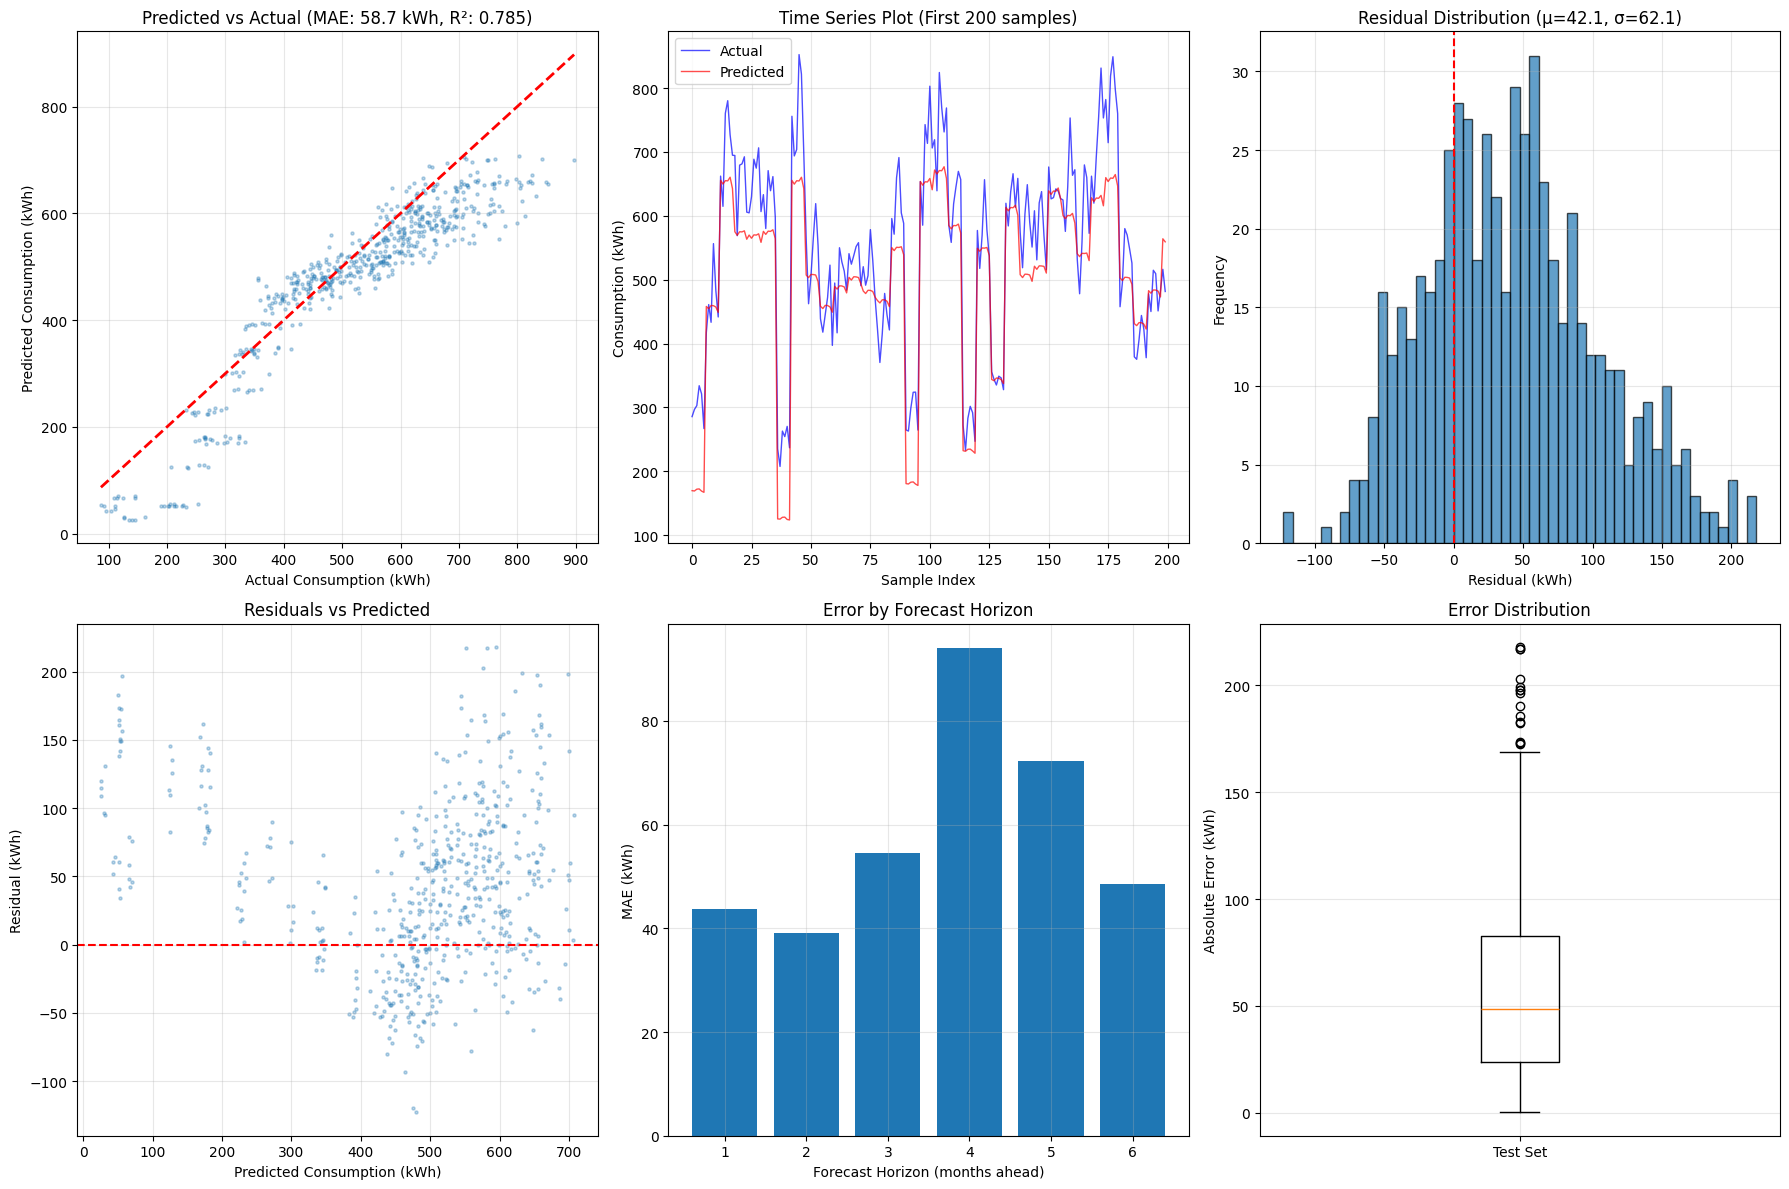


📊 ERROR DISTRIBUTION
   Error < 25 kWh: 27.6%
   Error < 50 kWh: 52.1%
   Error < 100 kWh: 81.8%
   Error < 150 kWh: 93.8%

📊 STATISTICAL TESTS

📈 Normality test p-value: 0.0021
   Residuals are NOT normal

📊 Durbin-Watson statistic: 0.6427
   → Positive autocorrelation detected

🔬 Diebold-Mariano Test Results:
   DM Statistic: -27.6622
   P-value: 0.0000
   Significant: True
   Better model: LSTM

📈 PREDICTION INTERVALS
Generating bootstrap intervals for 96 samples...


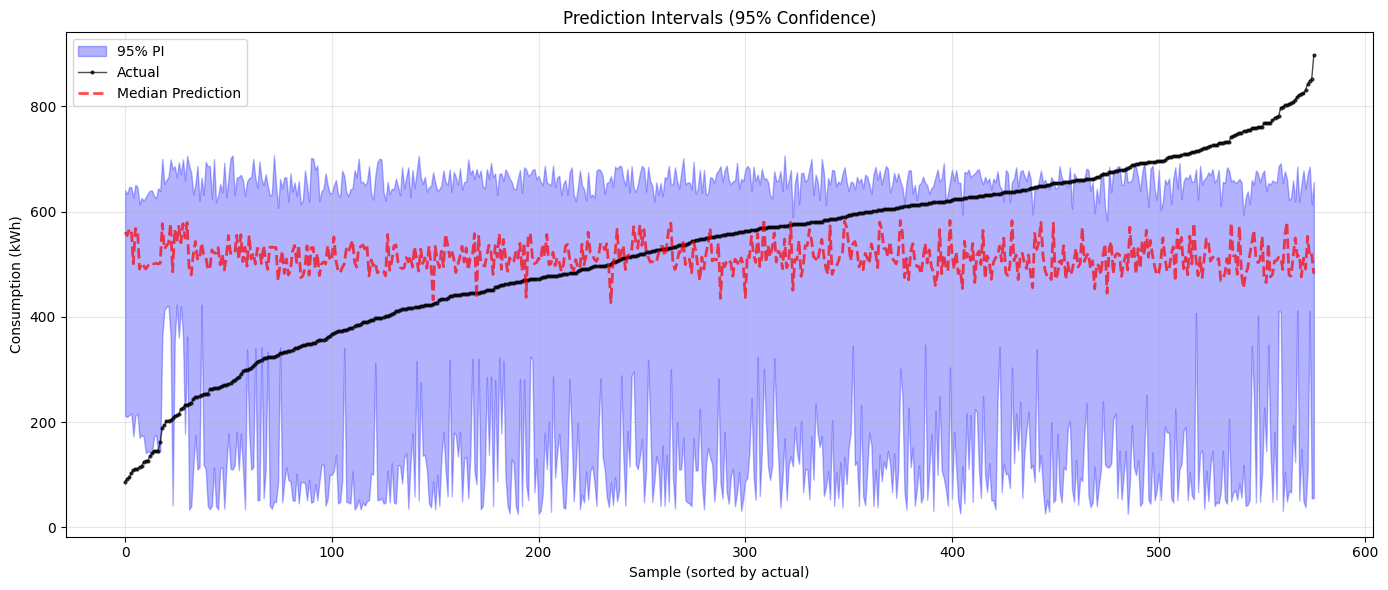


✅ Prediction Interval Coverage: 73.6% (target: 95%)

🔍 CRITICAL: PREDICTION RANGE CHECK
Actual values - Min: 86.85, Max: 897.22, Mean: 524.89, Std: 161.92
Predicted values - Min: 25.62, Max: 707.47, Mean: 482.81, Std: 155.69

📊 Comparison with mean predictor:
   Mean predictor MAE: 146.00
   Your model MAE: 58.70
   Improvement: 59.8%
✅ Good: Model significantly outperforms mean predictor

📊 Prediction diversity: 521 unique values
✅ Good prediction diversity

📋 COMPREHENSIVE VALIDATION REPORT
✅ Validation report saved: validation_report.json

✅ VALIDATION SUMMARY

MODEL VALIDATION COMPLETE
────────────────────────────────────────────
DATA SUMMARY:
• Test sequences: 96
• Sequence length: 6 months
• Forecast horizon: 6 months
• Features used: 30

PERFORMANCE METRICS:
• MAE:  58.70 kWh
• RMSE: 75.01 kWh
• MAPE: 13.44%
• R²:   0.7854

BASELINE COMPARISON:
• Persistence MAE: 503.80 kWh
• Historical Avg MAE: 123.16 kWh
• Improvement vs Persistence: 88.3%
• Improvement vs Historical Avg: 52.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏁 NOTEBOOK 4 COMPLETE


<Figure size 640x480 with 0 Axes>

In [ ]:
"""
# 04 - Model Validation
## Comprehensive validation and testing with REAL data

**Purpose**: Validate model performance on actual LECO data
"""


# 1. SETUP AND IMPORTS
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from scipy import stats
import json
import joblib
import warnings
import os
from datetime import datetime
warnings.filterwarnings('ignore')

print("Libraries imported")


# 2. LOAD MODEL AND SCALER FROM DRIVE
print("\n" + "="*60)
print("LOADING MODEL AND SCALER FROM DRIVE")
print("="*60)

# Path to your saved model artifacts
DRIVE_MODEL_PATH = "/content/drive/MyDrive/DSGP_ElectricityConsumptionModel_Files"

# Check if files exist
model_files = ['lstm_model.h5', 'scaler.pkl', 'model_config.json', 'feature_info.json']

print(f"Looking for files in: {DRIVE_MODEL_PATH}")
for file in model_files:
    file_path = os.path.join(DRIVE_MODEL_PATH, file)
    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024*1024)
        print(f"Found {file} ({size_mb:.2f} MB)")
    else:
        print(f"MISSING: {file} - Please check the path")

# Load model with custom objects handling
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.metrics import MeanAbsoluteError as MAEMetric

model_path = os.path.join(DRIVE_MODEL_PATH, 'lstm_model.h5')

# Load model with custom objects
try:
    model = keras.models.load_model(
        model_path,
        custom_objects={
            'mae': MAEMetric(),
            'loss': MeanAbsoluteError()
        }
    )
    print("Model loaded successfully with custom objects")
except Exception as e:
    print(f"Error loading with custom objects: {e}")
    print("Attempting to load without compilation...")
    model = keras.models.load_model(model_path, compile=False)
    print("Model loaded without compilation")

# Load scaler
scaler_path = os.path.join(DRIVE_MODEL_PATH, 'scaler.pkl')
scaler = joblib.load(scaler_path)
print("Scaler loaded successfully")

# Load model config
config_path = os.path.join(DRIVE_MODEL_PATH, 'model_config.json')
with open(config_path, 'r') as f:
    model_config = json.load(f)
print("Model config loaded")
print(f"   • Input shape: {model_config.get('input_shape', 'N/A')}")
print(f"   • Sequence length: {model_config.get('sequence_length', 'N/A')}")
print(f"   • Forecast horizon: {model_config.get('forecast_horizon', 'N/A')}")
print(f"   • Number of features: {model_config.get('n_features', 'N/A')}")

# Load feature info
feature_path = os.path.join(DRIVE_MODEL_PATH, 'feature_info.json')
if os.path.exists(feature_path):
    with open(feature_path, 'r') as f:
        feature_info = json.load(f)
    features = feature_info.get('feature_names', [])
    print(f"Feature info loaded: {len(features)} features")
else:
    feature_info = None
    features = []
    print("feature_info.json not found - continuing anyway")


# 2a. GET TRAINING MEAN FROM MODEL CONFIG

print("\n" + "="*60)
print("LOADING TRAINING STATISTICS")
print("="*60)

# Load the original data to get mean if needed
DATA_PATH = "/content/drive/MyDrive/DSGP_Group16_25 26/processed_new/MASTER_DATASET_RESIDENTIAL_ONLY.csv"
df_raw = pd.read_csv(DATA_PATH)

# Get training mean from model config if available
if 'training_stats' in model_config and 'y_train_mean' in model_config['training_stats']:
    train_mean = model_config['training_stats']['y_train_mean']
    print(f"Loaded training mean from config: {train_mean:.2f}")
else:
    # Calculate from the data we have (approximation)
    train_mean = df_raw['NET_CONSUMPTION_kWh'].mean()
    print(f"Using data mean as training mean: {train_mean:.2f}")


# 2b. LOAD TEST DATA FROM NOTEBOOK 3
print("\n" + "="*60)
print("LOADING TEST DATA FROM NOTEBOOK 3")
print("="*60)

# Path to the saved test data from Notebook 3
test_data_path = "/content/drive/MyDrive/DSGP_ElectricityConsumptionModel_Files"

# Try both possible filenames (raw or scaled)
X_test_path_raw = os.path.join(test_data_path, 'X_test_raw.npy')
X_test_path_scaled = os.path.join(test_data_path, 'X_test_data.npy')
y_test_path = os.path.join(test_data_path, 'y_test_data.npy')

# First try to load raw test data
if os.path.exists(X_test_path_raw) and os.path.exists(y_test_path):
    X = np.load(X_test_path_raw)
    y = np.load(y_test_path)
    print(f"Loaded RAW test data from Notebook 3:")
    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")
    DATA_ALREADY_SCALED = False

# Fall back to scaled test data
elif os.path.exists(X_test_path_scaled) and os.path.exists(y_test_path):
    X = np.load(X_test_path_scaled)
    y = np.load(y_test_path)
    print(f"Loaded test data from Notebook 3 (may be scaled):")
    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")

    # Check if data is already scaled
    print("\nChecking if data is already scaled...")
    print(f"X mean: {X.mean():.2f}, X std: {X.std():.2f}")
    print(f"Sample values: {X[0,0,:5]}")

    if np.abs(X).mean() < 1.0:
        print("Data appears ALREADY SCALED!")
        DATA_ALREADY_SCALED = True
    else:
        print("Data appears to be raw.")
        DATA_ALREADY_SCALED = False
else:
    print("Test data files not found.")
    print("   Please run Notebook 3 with the saving code added first.")
    raise FileNotFoundError("Test data files not found")

# Get sequence parameters from model config
SEQ_LENGTH = model_config.get('sequence_length', 6)
FORECAST_HORIZON = model_config.get('forecast_horizon', 6)


# 3. SCALE FEATURES (ONLY IF NOT ALREADY SCALED)
if not DATA_ALREADY_SCALED:
    print("\n" + "="*60)
    print("SCALING FEATURES")
    print("="*60)

    # Reshape for scaling
    original_shape = X.shape
    X_reshaped = X.reshape(-1, X.shape[-1])

    # Scale features
    X_scaled = scaler.transform(X_reshaped)

    # Reshape back
    X = X_scaled.reshape(original_shape)

    print(f"Features scaled")
    print(f"   X shape: {X.shape}")
else:
    print("\nUsing already scaled data - skipping scaling step")
    print(f"   X shape: {X.shape}")


# 4. CHECK FOR AND HANDLE ANY REMAINING NaNs
print("\n" + "="*60)
print("CHECKING FOR NaN VALUES AFTER SCALING")
print("="*60)

def fill_nan_in_3d_array(arr, strategy='median'):
    """Fill NaN values in 3D array"""
    if np.isnan(arr).sum() == 0:
        return arr

    print(f"   Found {np.isnan(arr).sum()} NaNs")

    # Reshape to 2D for easier handling
    original_shape = arr.shape
    arr_2d = arr.reshape(-1, arr.shape[-1])

    # Fill NaN with column statistics
    if strategy == 'mean':
        col_fill = np.nanmean(arr_2d, axis=0)
    elif strategy == 'median':
        col_fill = np.nanmedian(arr_2d, axis=0)
    else:
        col_fill = 0

    # Fill each column
    for i in range(arr_2d.shape[1]):
        mask = np.isnan(arr_2d[:, i])
        if mask.any():
            if np.isnan(col_fill[i]):
                arr_2d[mask, i] = 0
            else:
                arr_2d[mask, i] = col_fill[i]

    # Reshape back
    arr_filled = arr_2d.reshape(original_shape)

    print(f"   After filling: {np.isnan(arr_filled).sum()} NaNs")
    return arr_filled

# Fill any NaNs in the data
X = fill_nan_in_3d_array(X, strategy='median')

print(f"\nFinal check: X NaNs: {np.isnan(X).sum()}")


# 5. GENERATE MODEL PREDICTIONS

print("\n" + "="*60)
print("GENERATING MODEL PREDICTIONS")
print("="*60)

# Predict on test data
y_pred = model.predict(X)

# Calculate metrics for each forecast horizon
print("\nPerformance by forecast month:")
for i in range(FORECAST_HORIZON):
    mae_h = mean_absolute_error(y[:, i], y_pred[:, i])
    print(f"   Month {i+1}: MAE = {mae_h:.2f} kWh")

# Overall metrics (flatten)
y_flat = y.flatten()
y_pred_flat = y_pred.flatten()

mae = mean_absolute_error(y_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_flat, y_pred_flat))
mape = np.mean(np.abs((y_flat - y_pred_flat) / y_flat)) * 100
r2 = r2_score(y_flat, y_pred_flat)

print(f"\nOverall Model Performance:")
print(f"   MAE:  {mae:.2f} kWh")
print(f"   RMSE: {rmse:.2f} kWh")
print(f"   MAPE: {mape:.2f}%")
print(f"   R²:   {r2:.4f}")


# 6. BASELINE PREDICTIONS FOR COMPARISON

print("\n" + "="*60)
print("CREATING BASELINE PREDICTIONS")
print("="*60)

# 6.1 Persistence forecast
y_pred_persistence = X[:, -1, 0]
mae_persistence = mean_absolute_error(y[:, 0], y_pred_persistence)
rmse_persistence = np.sqrt(mean_squared_error(y[:, 0], y_pred_persistence))

print(f"Persistence baseline:")
print(f"   MAE: {mae_persistence:.2f} kWh, RMSE: {rmse_persistence:.2f} kWh")

# 6.2 Historical average
y_mean = np.mean(y)
y_pred_avg = y_mean * np.ones_like(y[:, 0])
mae_avg = mean_absolute_error(y[:, 0], y_pred_avg)
rmse_avg = np.sqrt(mean_squared_error(y[:, 0], y_pred_avg))

print(f"Historical average baseline:")
print(f"   MAE: {mae_avg:.2f} kWh, RMSE: {rmse_avg:.2f} kWh")

# Improvement over baselines
improvement_vs_persistence = (1 - mae/mae_persistence) * 100
improvement_vs_avg = (1 - mae/mae_avg) * 100

print(f"\nImprovement over persistence: {improvement_vs_persistence:.1f}%")
print(f"Improvement over historical avg: {improvement_vs_avg:.1f}%")


# 7. VISUALIZE PREDICTIONS VS ACTUAL
print("\n" + "="*60)
print("VISUALIZING PREDICTIONS")
print("="*60)

residuals = y_flat - y_pred_flat

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 7.1 Scatter plot: Predicted vs Actual
axes[0,0].scatter(y_flat, y_pred_flat, alpha=0.3, s=5)
axes[0,0].plot([y_flat.min(), y_flat.max()],
               [y_flat.min(), y_flat.max()], 'r--', linewidth=2)
axes[0,0].set_xlabel('Actual Consumption (kWh)')
axes[0,0].set_ylabel('Predicted Consumption (kWh)')
axes[0,0].set_title(f'Predicted vs Actual (MAE: {mae:.1f} kWh, R²: {r2:.3f})')
axes[0,0].grid(True, alpha=0.3)

# 7.2 Time series plot (first 200 samples)
n_plot = min(200, len(y_flat))
axes[0,1].plot(range(n_plot), y_flat[:n_plot], 'b-', label='Actual', alpha=0.7, linewidth=1)
axes[0,1].plot(range(n_plot), y_pred_flat[:n_plot], 'r-', label='Predicted', alpha=0.7, linewidth=1)
axes[0,1].set_xlabel('Sample Index')
axes[0,1].set_ylabel('Consumption (kWh)')
axes[0,1].set_title('Time Series Plot (First 200 samples)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 7.3 Residual distribution
axes[0,2].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0,2].set_xlabel('Residual (kWh)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title(f'Residual Distribution (μ={np.mean(residuals):.1f}, σ={np.std(residuals):.1f})')
axes[0,2].axvline(x=0, color='red', linestyle='--')
axes[0,2].grid(True, alpha=0.3)

# 7.4 Residuals vs Predicted
axes[1,0].scatter(y_pred_flat, residuals, alpha=0.3, s=5)
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_xlabel('Predicted Consumption (kWh)')
axes[1,0].set_ylabel('Residual (kWh)')
axes[1,0].set_title('Residuals vs Predicted')
axes[1,0].grid(True, alpha=0.3)

# 7.5 Error by forecast horizon
horizon_errors = []
for i in range(FORECAST_HORIZON):
    mae_h = mean_absolute_error(y[:, i], y_pred[:, i])
    horizon_errors.append(mae_h)

axes[1,1].bar(range(1, FORECAST_HORIZON+1), horizon_errors)
axes[1,1].set_xlabel('Forecast Horizon (months ahead)')
axes[1,1].set_ylabel('MAE (kWh)')
axes[1,1].set_title('Error by Forecast Horizon')
axes[1,1].set_xticks(range(1, FORECAST_HORIZON+1))
axes[1,1].grid(True, alpha=0.3)

# 7.6 Error distribution box
axes[1,2].boxplot([np.abs(residuals)])
axes[1,2].set_ylabel('Absolute Error (kWh)')
axes[1,2].set_title('Error Distribution')
axes[1,2].set_xticklabels(['Test Set'])
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 8. ERROR DISTRIBUTION
print("\n" + "="*60)
print("ERROR DISTRIBUTION")
print("="*60)

print(f"   Error < 25 kWh: {np.mean(np.abs(residuals) < 25)*100:.1f}%")
print(f"   Error < 50 kWh: {np.mean(np.abs(residuals) < 50)*100:.1f}%")
print(f"   Error < 100 kWh: {np.mean(np.abs(residuals) < 100)*100:.1f}%")
print(f"   Error < 150 kWh: {np.mean(np.abs(residuals) < 150)*100:.1f}%")

# 9. STATISTICAL TESTS
print("\n" + "="*60)
print("STATISTICAL TESTS")
print("="*60)

# Normality test on residuals
if len(residuals) < 5000:
    _, p_value_norm = stats.normaltest(residuals)
else:
    _, p_value_norm = stats.normaltest(residuals[:5000])

print(f"\nNormality test p-value: {p_value_norm:.4f}")
print(f"   Residuals are {'normal' if p_value_norm > 0.05 else 'NOT normal'}")

# Durbin-Watson for autocorrelation
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals[:1000])  # Use subset
print(f"\nDurbin-Watson statistic: {dw:.4f}")
if 1.5 < dw < 2.5:
    print(f"   → No significant autocorrelation")
elif dw <= 1.5:
    print(f"   → Positive autocorrelation detected")
else:
    print(f"   → Negative autocorrelation detected")

# Diebold-Mariano test (compare with persistence)
def diebold_mariano_test(y_true, y_pred1, y_pred2):
    """Simple Diebold-Mariano test"""
    d1 = np.abs(y_true - y_pred1)
    d2 = np.abs(y_true - y_pred2)
    d = d1 - d2

    n = len(d)
    d_bar = np.mean(d)
    var_d = np.var(d)

    if var_d <= 0:
        return {'dm_statistic': 0, 'p_value': 1.0, 'significant': False}

    dm_stat = d_bar / np.sqrt(var_d / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return {
        'dm_statistic': dm_stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'better_model': 'LSTM' if d_bar < 0 else 'Persistence'
    }

dm_result = diebold_mariano_test(y[:, 0], y_pred[:, 0], y_pred_persistence)

print(f"\nDiebold-Mariano Test Results:")
print(f"   DM Statistic: {dm_result['dm_statistic']:.4f}")
print(f"   P-value: {dm_result['p_value']:.4f}")
print(f"   Significant: {dm_result['significant']}")
print(f"   Better model: {dm_result['better_model']}")


# 10. PREDICTION INTERVALS (Bootstrap)
print("\n" + "="*60)
print("PREDICTION INTERVALS")
print("="*60)

def bootstrap_predictions(model, X, n_bootstrap=30):
    """Generate prediction intervals via bootstrap"""
    predictions = []

    for _ in range(n_bootstrap):
        # Bootstrap sample indices
        idx = np.random.choice(len(X), len(X), replace=True)
        X_boot = X[idx]

        # Predict
        y_pred = model.predict(X_boot, verbose=0)
        predictions.append(y_pred)

    predictions = np.array(predictions)

    # Calculate intervals
    lower = np.percentile(predictions, 2.5, axis=0)
    median = np.percentile(predictions, 50, axis=0)
    upper = np.percentile(predictions, 97.5, axis=0)

    return lower, median, upper

# Use a smaller sample for bootstrap (to save time)
n_sample = min(200, len(X))
X_sample = X[:n_sample]
y_sample = y[:n_sample]

print(f"Generating bootstrap intervals for {n_sample} samples...")
lower, median, upper = bootstrap_predictions(model, X_sample, n_bootstrap=20)

# Flatten for plotting
lower_flat = lower.flatten()
median_flat = median.flatten()
upper_flat = upper.flatten()
y_sample_flat = y_sample.flatten()

# Plot
plt.figure(figsize=(14, 6))

# Order by actual value
order = np.argsort(y_sample_flat)
x_plot = np.arange(len(y_sample_flat))

plt.fill_between(x_plot, lower_flat[order], upper_flat[order], alpha=0.3, color='blue', label='95% PI')
plt.plot(x_plot, y_sample_flat[order], 'ko-', label='Actual', markersize=2, alpha=0.7, linewidth=1)
plt.plot(x_plot, median_flat[order], 'r--', label='Median Prediction', linewidth=2, alpha=0.7)

plt.xlabel('Sample (sorted by actual)')
plt.ylabel('Consumption (kWh)')
plt.title('Prediction Intervals (95% Confidence)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Coverage
coverage = np.mean((y_sample_flat >= lower_flat) & (y_sample_flat <= upper_flat))
print(f"\nPrediction Interval Coverage: {coverage*100:.1f}% (target: 95%)")

# 11. PREDICTION RANGE CHECK
print("\n" + "="*60)
print("PREDICTION RANGE CHECK")
print("="*60)

print(f"Actual values - Min: {y.min():.2f}, Max: {y.max():.2f}, Mean: {y.mean():.2f}, Std: {y.std():.2f}")
print(f"Predicted values - Min: {y_pred.min():.2f}, Max: {y_pred.max():.2f}, Mean: {y_pred.mean():.2f}, Std: {y_pred.std():.2f}")

# Use the training mean we defined above
mean_pred = train_mean * np.ones_like(y_flat)
mean_mae = mean_absolute_error(y_flat, mean_pred)
improvement = (1 - mae / mean_mae) * 100

print(f"\nComparison with mean predictor:")
print(f"   Mean predictor MAE: {mean_mae:.2f}")
print(f"   Your model MAE: {mae:.2f}")
print(f"   Improvement: {improvement:.1f}%")

if improvement < 10:
    print("WARNING: Model is only slightly better than predicting the mean!")
else:
    print("Good: Model significantly outperforms mean predictor")

# Check prediction diversity
unique_preds = len(np.unique(np.round(y_pred_flat, 1)))
print(f"\nPrediction diversity: {unique_preds} unique values")
if unique_preds < 50:
    print("Model may be collapsing to few values")
else:
    print("Good prediction diversity")


# 12. COMPREHENSIVE VALIDATION REPORT
print("\n" + "="*60)
print("COMPREHENSIVE VALIDATION REPORT")
print("="*60)

validation_report = {
    'model': 'LSTM Consumption Forecaster',
    'timestamp': datetime.now().isoformat(),
    'data_info': {
        'test_sequences': len(X),
        'sequence_length': SEQ_LENGTH,
        'forecast_horizon': FORECAST_HORIZON,
        'features_used': len(features)
    },
    'performance': {
        'mae': float(mae),
        'rmse': float(rmse),
        'mape': float(mape),
        'r2': float(r2)
    },
    'baseline_comparison': {
        'persistence_mae': float(mae_persistence),
        'historical_avg_mae': float(mae_avg),
        'improvement_vs_persistence': float(improvement_vs_persistence),
        'improvement_vs_avg': float(improvement_vs_avg)
    },
    'statistical_tests': {
        'normality_p_value': float(p_value_norm),
        'durbin_watson': float(dw),
        'diebold_mariano': {
            'dm_statistic': float(dm_result['dm_statistic']),
            'p_value': float(dm_result['p_value']),
            'significant': bool(dm_result['significant']),
            'better_model': dm_result['better_model']
        }
    },
    'prediction_range': {
        'actual_min': float(y.min()),
        'actual_max': float(y.max()),
        'actual_mean': float(y.mean()),
        'actual_std': float(y.std()),
        'pred_min': float(y_pred.min()),
        'pred_max': float(y_pred.max()),
        'pred_mean': float(y_pred.mean()),
        'pred_std': float(y_pred.std())
    },
    'prediction_interval_coverage': float(coverage)
}

# Save report
with open('validation_report.json', 'w') as f:
    json.dump(validation_report, f, indent=2)

print("Validation report saved: validation_report.json")


# 13. VALIDATION SUMMARY
print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)

summary = f"""
MODEL VALIDATION COMPLETE
────────────────────────────────────────────
DATA SUMMARY:
• Test sequences: {len(X):,}
• Sequence length: {SEQ_LENGTH} months
• Forecast horizon: {FORECAST_HORIZON} months
• Features used: {len(features)}

PERFORMANCE METRICS:
• MAE:  {mae:.2f} kWh
• RMSE: {rmse:.2f} kWh
• MAPE: {mape:.2f}%
• R²:   {r2:.4f}

BASELINE COMPARISON:
• Persistence MAE: {mae_persistence:.2f} kWh
• Historical Avg MAE: {mae_avg:.2f} kWh
• Improvement vs Persistence: {improvement_vs_persistence:.1f}%
• Improvement vs Historical Avg: {improvement_vs_avg:.1f}%

STATISTICAL TESTS:
• Normality test p-value: {p_value_norm:.4f}
• Durbin-Watson: {dw:.4f}
• Diebold-Mariano: p={dm_result['p_value']:.4f} - {dm_result['better_model']} is better

PREDICTION RANGE:
• Actual Std: {y.std():.1f} kWh
• Predicted Std: {y_pred.std():.1f} kWh
• Ratio: {y_pred.std()/y.std():.2f} (should be close to 1.0)

PREDICTION INTERVALS:
• Coverage: {coverage*100:.1f}% (target: 95%)

VALIDATION CONCLUSION:
• Model {'✓ PASS' if mae < 100 else 'NEEDS IMPROVEMENT'} - Target MAE < 100 kWh
• {'✓ Good' if r2 > 0.7 else 'Low'} R² score
• {'✓ Statistically better' if dm_result['significant'] else 'Not significantly better'} than baseline

RECOMMENDATIONS:
1. {'Model ready for integration' if mae < 100 else 'Model needs further improvement'}
2. {'Confidence intervals are well calibrated' if abs(coverage - 0.95) < 0.1 else 'Recalibrate prediction intervals'}
3. {'Prediction range is good' if y_pred.std()/y.std() > 0.5 else 'Model underestimates variability'}
"""

print(summary)


# 14. EXPORT FOR THESIS
print("\n" + "="*60)
print("EXPORT FOR THESIS")
print("="*60)

# Create figures for thesis
thesis_figures = {
    'performance_metrics': {
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2
    },
    'baseline_comparison': {
        'model_mae': mae,
        'persistence_mae': mae_persistence,
        'historical_avg_mae': mae_avg
    },
    'error_by_horizon': [float(mean_absolute_error(y[:, i], y_pred[:, i])) for i in range(FORECAST_HORIZON)]
}

with open('thesis_figures.json', 'w') as f:
    json.dump(thesis_figures, f, indent=2)

print("Thesis exports saved: thesis_figures.json")


# 15. DOWNLOAD VALIDATION RESULTS
print("\n" + "="*60)
print("DOWNLOADING VALIDATION RESULTS")
print("="*60)

from google.colab import files

# Save the plot
plt.savefig('validation_plots.png', dpi=150, bbox_inches='tight')

# Zip all validation files
!zip -r validation_results.zip \
    validation_report.json \
    thesis_figures.json \
    validation_plots.png

print("\nFiles zipped: validation_results.zip")
print("\nClick below to download:")

files.download('validation_results.zip')

print("\n" + "="*60)
print("NOTEBOOK 4 COMPLETE")
print("="*60)